In [1]:
print('My name is', '\n', 'Anthony Mensah','\n','\n')

My name is 
 Anthony Mensah 
 



In [2]:
print('My student ID is', '\n', '38719''\n')

My student ID is 
 38719



In [3]:
from datetime import datetime
print(datetime.now())

2026-03-06 06:19:00.406117


In [4]:
from datetime import date
from datetime import datetime
import math 

tday = date.today()

# weekdays as a tuple
weekDays = ("Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday")
weekday  = tday.weekday()

# time below
now = datetime.now()
current_time = now.strftime("%H:%M:%S")

print('Today is {} {} {}'.format(date.today(), weekDays[weekday], current_time))

Today is 2026-03-06 Friday 06:19:00


In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
def get_prices(tickers, start, end):

    data = yf.download(tickers, start=start, end=end)

    if "Adj Close" in data.columns:
        data = data["Adj Close"]
    else:
        data = data["Close"]

    return data

In [7]:
def normalize_prices(df):
    return (df / df.iloc[0] - 1) * 100

In [8]:
tickers = ["SPYG","VOO","SPY","SCHD","SPHD"]

In [9]:
data = get_prices(tickers,"2012-10-31","2026-02-27")

# normalize price to start at 1
norm = data / data.iloc[0]
norm.head()

[*********************100%***********************]  5 of 5 completed


Ticker,SCHD,SPHD,SPY,SPYG,VOO
Date,,,,,
2012-10-31,1.000000,1.000000,1.000000,1.000000,1.000000
2012-11-01,1.007373,1.002792,1.010470,1.011322,1.011759
2012-11-02,0.998595,0.989624,1.001486,1.000765,1.002630
2012-11-05,0.998947,0.985235,1.003537,1.005508,1.004951
2012-11-06,1.006671,0.991220,1.011390,1.009792,1.012378


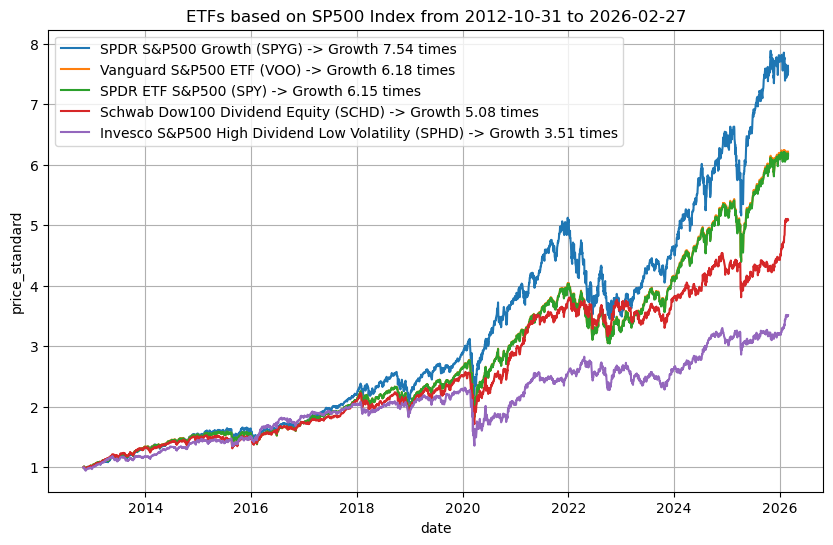

In [10]:
names = {
"SPYG":"SPDR S&P500 Growth (SPYG)",
"VOO":"Vanguard S&P500 ETF (VOO)",
"SPY":"SPDR ETF S&P500 (SPY)",
"SCHD":"Schwab Dow100 Dividend Equity (SCHD)",
"SPHD":"Invesco S&P500 High Dividend Low Volatility (SPHD)"
}

plt.figure(figsize=(10,6))

for ticker in tickers:

    growth = norm[ticker].iloc[-1]

    label = f"{names[ticker]} -> Growth {growth:.2f} times"

    plt.plot(norm.index, norm[ticker], label=label)

plt.title("ETFs based on SP500 Index from 2012-10-31 to 2026-02-27")
plt.xlabel("date")
plt.ylabel("price_standard")

plt.legend()
plt.grid(True)

plt.show()

In [11]:
indexes = ["^BSESN","^KS11","^GSPC","^N225","^STOXX","^HSI"]

In [12]:
data2 = get_prices(indexes,"2004-04-27","2026-02-27")

norm2 = normalize_prices(data2)
norm2.head()

[*********************100%***********************]  6 of 6 completed


Ticker,^BSESN,^GSPC,^HSI,^KS11,^N225,^STOXX
Date,,,,,,
2004-04-27,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2004-04-28,0.014181,-1.379476,0.085557,-1.489940,-0.336988,-1.433660
2004-04-29,-0.767638,-2.128087,-1.228558,-4.375894,NaN,-2.296290
2004-04-30,-1.001175,-2.707114,-1.743741,-5.748954,-2.350292,-3.187265
2004-05-03,-2.228349,-1.811775,-1.680720,-5.391765,NaN,-2.644581


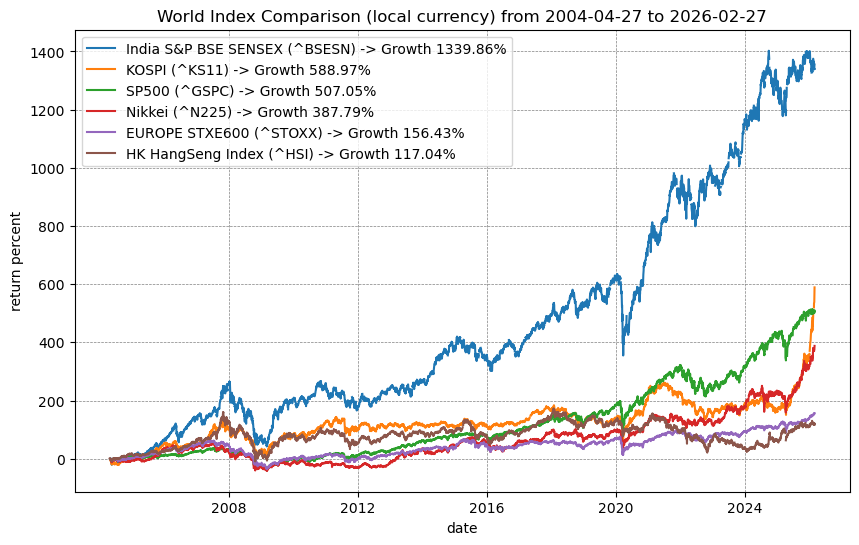

In [13]:
names = {
"^BSESN":"India S&P BSE SENSEX (^BSESN)",
"^KS11":"KOSPI (^KS11)",
"^GSPC":"SP500 (^GSPC)",
"^N225":"Nikkei (^N225)",
"^STOXX":"EUROPE STXE600 (^STOXX)",
"^HSI":"HK HangSeng Index (^HSI)"
}

plt.figure(figsize=(10,6))

for idx in indexes:

    growth = norm2[idx].iloc[-1]

    plt.plot(norm2.index, norm2[idx],
             label=f"{names[idx]} -> Growth {growth:.2f}%")

plt.title("World Index Comparison (local currency) from 2004-04-27 to 2026-02-27")
plt.xlabel("date")
plt.ylabel("return percent")

plt.legend()
plt.grid(True, axis='both', color='gray', linestyle='--', linewidth=0.5)

plt.xticks(["2008-01-01","2012-01-01","2016-01-01","2020-01-01","2024-01-01"],
           ["2008","2012","2016","2020","2024"])

plt.show()

In [14]:
fx = yf.download(["JPY=X","KRW=X","INR=X","HKD=X","EURUSD=X"],
                 start="2004-04-27",
                 end="2026-02-27",
                 auto_adjust=True)["Close"]

fx.head()

[*********************100%***********************]  5 of 5 completed


Ticker,EURUSD=X,HKD=X,INR=X,JPY=X,KRW=X
Date,,,,,
2004-04-27,1.192905,7.7991,44.071999,109.519997,1152.500000
2004-04-28,1.184301,7.7961,44.105999,110.019997,1144.500000
2004-04-29,1.196001,7.7989,44.319000,109.930000,1169.599976
2004-04-30,1.198294,7.7996,44.284000,110.370003,1162.699951
2004-05-03,1.193602,7.7975,44.292000,110.160004,1160.099976


In [15]:
indexes_usd = ["^BSESN","^KS11","^N225","^STOXX","^HSI"]

In [16]:
usd_data = data2.copy()

usd_data["^N225"] = usd_data["^N225"] / fx["JPY=X"]
usd_data["^KS11"] = usd_data["^KS11"] / fx["KRW=X"]
usd_data["^BSESN"] = usd_data["^BSESN"] / fx["INR=X"]
usd_data["^HSI"] = usd_data["^HSI"] / fx["HKD=X"]

In [17]:
norm3 = normalize_prices(usd_data)

In [18]:
names = {
"^BSESN":"India S&P BSE SENSEX (^BSESN)",
"^KS11":"KOSPI (^KS11)",
"^N225":"Nikkei (^N225)",
"^STOXX":"Europe STXE600 (^STOXX)",
"^HSI":"HK HangSeng Index (^HSI)"
}

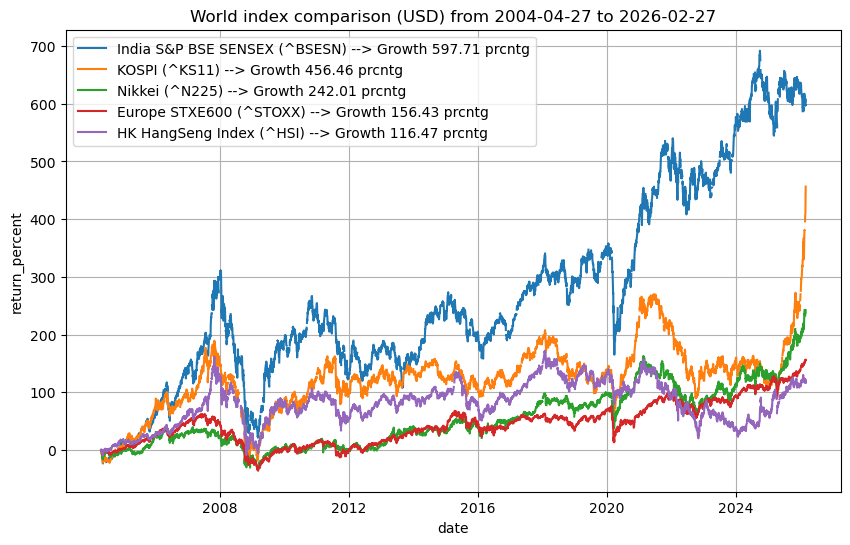

In [19]:
plt.figure(figsize=(10,6))

for idx in indexes_usd:

    growth = norm3[idx].iloc[-1]

    plt.plot(norm3.index,
             norm3[idx],
             label=f"{names[idx]} --> Growth {growth:.2f} prcntg")

plt.title("World index comparison (USD) from 2004-04-27 to 2026-02-27")
plt.xlabel("date")
plt.ylabel("return_percent")

plt.legend()
plt.grid(True)

plt.xticks(["2008-01-01","2012-01-01","2016-01-01","2020-01-01","2024-01-01"],
           ["2008","2012","2016","2020","2024"])

plt.show()